# 1. Library import

In [1]:
import os
from functools import partial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import kstest, skew, kurtosis

from volatility_pipeline.models import (
    GARCHModel, make_garch,
    param_matrix,
    pvalue_matrix, asymmetry_summary, persistence, equations_markdown, scale_note,
)
from volatility_pipeline.evaluation import (
    RollingEvaluator,
    ForecastResult,
    dm_matrix,
    dm_family_split,
    mcs,
    arch_mcs,
    garman_klass,
    parkinson,
    squared_returns,
    forecast_diagnostics,
    normality_report,
)

# 2. Notebook variables set up

In [2]:
# ── Input data variables ────────────────────────────────────────────────────
TICKER          = "NG=F"
FULL_DATA_START = "2010-01-01"
FULL_DATA_END   = "2026-06-30"

TRAIN_START = FULL_DATA_START
TRAIN_END   = "2022-06-30"
TEST_START  = "2022-07-01"
TEST_END    = FULL_DATA_END

# ── Classical econometric model specifications ───────────────────────────────
# Each tuple: (model_type, error_distribution)
# model_type:  'GARCH' | 'GJR-GARCH' | 'EGARCH' | 'APARCH' | 'FIGARCH'
# dist:        'normal' | 't' | 'ged'
GARCH_SPECS = [
    ("GARCH",     "normal"),
    ("GARCH",     "t"),
    ("GARCH",     "ged"),
    ("GJR-GARCH", "normal"),
    ("GJR-GARCH", "t"),
    ("GJR-GARCH", "ged"),
    ("EGARCH",    "normal"),
    ("EGARCH",    "t"),
    ("EGARCH",    "ged"),
    ("APARCH",    "normal"),
    ("APARCH",    "t"),
    ("APARCH",    "ged"),
    ("FIGARCH",   "normal"),
    ("FIGARCH",   "t"),
    ("FIGARCH",   "ged"),
]

# ASYM_ORDER sets the asymmetric (leverage) order `o` of the EGARCH and APARCH
# specifications, which are asymmetric by construction in the literature
# (Nelson 1991; Ding et al. 1993):
#   1 -> asymmetric: a leverage coefficient gamma is estimated (default)
#   0 -> symmetric variants instead (log-variance GARCH / plain Power ARCH)
# It is applied ONLY to EGARCH and APARCH. GARCH and GJR-GARCH are *defined* by
# o=0 and o=1 respectively (changing o would turn one into the other), and
# arch's FIGARCH has no asymmetric term — make_garch ignores the setting there.
# NOTE: arch_model()'s own default is o=0, so omitting it silently estimates the
# symmetric variant; that is why this is passed explicitly.
ASYM_ORDER = 1  # 1 | 0  — EGARCH / APARCH only

# ── Out-of-sample evaluation ─────────────────────────────────────────────────
N_AHEAD     = 1   # forecast horizon (steps ahead); only 1 is currently supported
REFIT_EVERY = 10  # re-estimate model parameters every N test steps

# WINDOW_TYPE controls the estimation scheme used during out-of-sample evaluation:
#   "expanding" — recursive: each step uses all data from the start up to t
#   "sliding"   — rolling: each step uses a fixed window of WINDOW_SIZE obs
WINDOW_TYPE = "expanding"  # 'expanding' | 'sliding'

# WINDOW_SIZE sets the sliding-window width in observations (ignored when
# WINDOW_TYPE="expanding"). None -> full training length (~3110 obs, ~12y),
# which overlaps almost entirely with the expanding window over a ~4y test and
# therefore shows negligible differences. Use a NARROW width to probe
# sensitivity to the 2020/2022 regime shifts, e.g. 750 (~3y) or 500 (~2y).
WINDOW_SIZE = None  # None | 750 | 500 | int (must be <= training length)

# VARIANCE_PROXY controls the realized-variance proxy used as the forecast target:
#   "garman_klass"  — Garman-Klass (1980): uses OHLC; 5-8× less noisy than r²
#   "parkinson"     — Parkinson (1980): uses High/Low only; simpler than GK
#   "squared"       — r²: noisiest, reduces DM/MCS power significantly
# Recommendation: use "garman_klass" as the primary proxy; r² for reference only.
VARIANCE_PROXY = "garman_klass"  # 'garman_klass' | 'parkinson' | 'squared'

# ── Statistical tests ────────────────────────────────────────────────────────
TEST_LOSS = "qlike"  # loss for DM test & MCS: 'squared' | 'absolute' | 'qlike'
MCS_ALPHA = 0.05     # MCS significance level  (0.10 → 90% MCS)
DM_ALPHA  = 0.05     # Diebold-Mariano rejection threshold

# ── Reproducibility ──────────────────────────────────────────────────────────
# RANDOM_SEED is passed to every bootstrap procedure in the pipeline (custom MCS
# and arch MCS).  Change this value to verify that results are stable across
# different seeds.  All other steps (GARCH fitting, DM test, proxy calculation,
# rolling evaluation) are fully deterministic and unaffected by this setting.
#
# N_BOOT controls the number of bootstrap replications used by both MCS
# implementations.  Higher values give more stable p-values at the cost of
# runtime.  1000 is the minimum recommended; 2000 is a safe default.
RANDOM_SEED = 42
N_BOOT      = 2000

# ── Parallelism ─────────────────────────────────────────────────────────────
# Controls RollingEvaluator.evaluate_many(n_jobs=...).
#   1  → sequential (safe with any callable including lambdas)
#  -1  → all available CPU cores
#   N  → exactly N worker processes
#
# NOTE — factory callables must be picklable when PARALLEL_JOBS != 1.
#   functools.partial (used below) is picklable. lambda is NOT.
PARALLEL_JOBS = -1   # -1 = all cores; change to 1 to run sequentially
print(f"CPUs available: {os.cpu_count()}  |  PARALLEL_JOBS={PARALLEL_JOBS}")

CPUs available: 10  |  PARALLEL_JOBS=-1


# 3. Import data

In [3]:
# Import data from Yahoo Finance (OHLC + Close needed for range-based proxies)
data   = yf.download(TICKER, start=FULL_DATA_START, end=FULL_DATA_END)
close  = data["Close"].squeeze()
open_  = data["Open"].squeeze()
high   = data["High"].squeeze()
low    = data["Low"].squeeze()

returns = np.log(close / close.shift(1)).dropna()

# Compute variance proxy on the original DatetimeIndex (before PeriodIndex conversion)
if VARIANCE_PROXY == "garman_klass":
    _proxy = garman_klass(
        open_.reindex(returns.index),
        high.reindex(returns.index),
        low.reindex(returns.index),
        close.reindex(returns.index),
    )
elif VARIANCE_PROXY == "parkinson":
    _proxy = parkinson(
        high.reindex(returns.index),
        low.reindex(returns.index),
    )
else:  # "squared"
    _proxy = squared_returns(returns)

# Convert both series to PeriodIndex for consistency with arch model indexing
returns.index = pd.PeriodIndex(returns.index, freq='D')
_proxy.index  = returns.index
variance_proxy = _proxy

print(f"Proxy: {VARIANCE_PROXY}  |  {len(variance_proxy)} observations")
print(f"  min={variance_proxy.min():.6e}  max={variance_proxy.max():.6e}  mean={variance_proxy.mean():.6e}")

[*********************100%***********************]  1 of 1 completed

Proxy: garman_klass  |  4146 observations
  min=1.151668e-06  max=9.273164e-02  mean=1.035716e-03


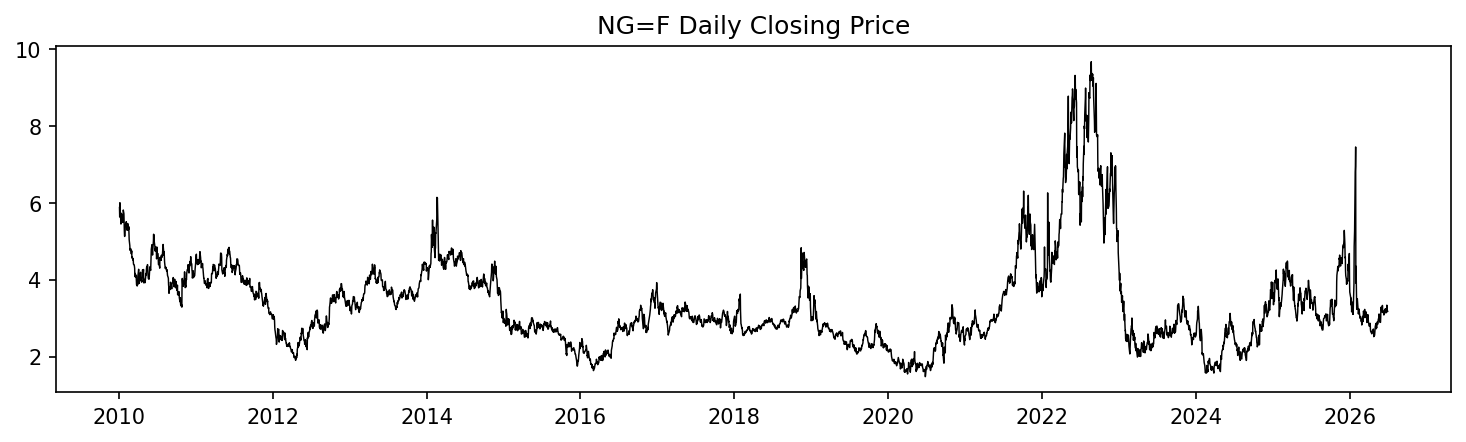

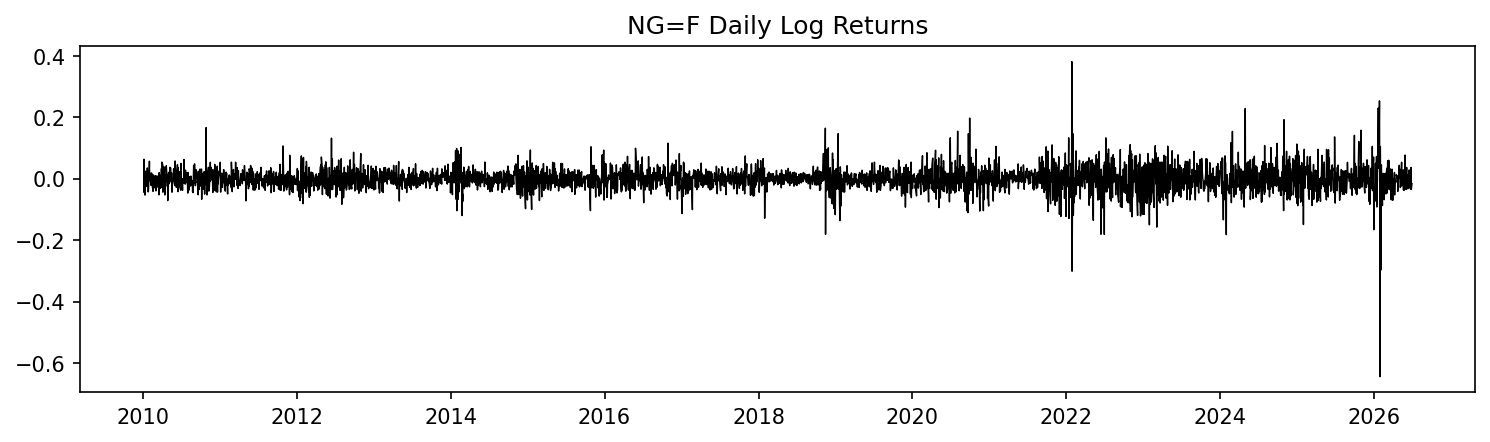

In [4]:
# Visualize the data
plt.figure(figsize=(12, 3), dpi=150)
plt.plot(close, linewidth=0.7, color='black')
plt.title(f"{TICKER} Daily Closing Price")
plt.show()

plt.figure(figsize=(12, 3), dpi=150)
plt.plot(returns.index.to_timestamp(), returns.values, label='Daily Returns', linewidth=0.7, color='black')
plt.title(f"{TICKER} Daily Log Returns")
plt.show()

In [5]:
def get_stats_and_ks(series, name):
    stats = series.describe()
    ks_stat, ks_pval = kstest(series, 'norm', args=(series.mean(), series.std()))
    result = {
        'count': stats['count'],
        'mean': stats['mean'],
        'std': stats['std'],
        'min': stats['min'],
        'max': stats['max'],
        'range': stats['max'] - stats['min'],
        'skewness': skew(series),
        'kurtosis': kurtosis(series),
        'KS_stat': ks_stat,
        'KS_pval': ks_pval,
        'Name': name
    }
    return result

stats_list = [
    get_stats_and_ks(returns, "Full Returns")
]

stats_df = pd.DataFrame(stats_list).set_index('Name')
stats_df


,count,mean,std,min,max,range,skewness,kurtosis,KS_stat,KS_pval
Name,,,,,,,,,,
Full Returns,4146.0,-0.000148,0.038327,-0.643974,0.381727,1.025701,-0.881501,25.907827,0.069182,1.066578e-17


## 3.1 Normality and serial-dependence diagnostics

The KS statistic reported above assumes the observations are **i.i.d.** Daily returns are approximately uncorrelated in the mean (white noise) but *not* independent — they show volatility clustering (strong dependence in squared returns). Under that dependence the i.i.d. KS / Jarque–Bera null distributions are invalid and tend to over-reject. We therefore (Layer 1) document the dependence, (Layer 2) test normality with a dependence-robust test (Bai & Ng 2005, HAC-corrected skewness/kurtosis), and (Layer 3) recompute the KS p-value with a stationary block bootstrap; Anderson–Darling is added for tail sensitivity.

**How to read the dependence tests below.** Each test's H₀ is "no dependence of that kind, up to the tested lag." Rejecting H₀ (p < α) means the data show statistically significant evidence *of* the effect being tested; failing to reject (p > α) means no such evidence was found at that significance level — this does **not** prove the effect is absent, only that this test didn't detect it.

- **Ljung-Box (returns)** — H₀: no autocorrelation in returns (mean is white noise). We *expect* p > α here: if this rejects instead, the mean itself is predictable, which would be a problem for the modelling that follows.
- **Ljung-Box (squared returns)** — H₀: no autocorrelation in squared returns. We *expect* p < α (a rejection) here — this is the volatility-clustering signal that motivates GARCH modelling in the first place.
- **Engle ARCH-LM** — H₀: no ARCH effects (squared returns are not linearly predictable from their own recent lags). Same expectation: p < α confirms ARCH effects are present.


In [6]:
# Layers 1-3 normality / serial-dependence diagnostics (see markdown above).
# Volatility clustering makes the i.i.d. KS test invalid; these address that.
norm_diag = normality_report(returns, name=TICKER, n_boot=N_BOOT, seed=RANDOM_SEED)

# Layer 1 - dependence: mean ~ white noise, variance strongly dependent
# (this is exactly why an i.i.d. distributional test on the levels is invalid).
norm_diag["dependence"].style.format(
    {"statistic": "{:.2f}", "p_value": "{:.2e}"}
).set_caption("Layer 1 - serial dependence: Ljung-Box (returns & squared) + Engle ARCH-LM")

,series,test,lag,statistic,p_value
0,NG=F,Ljung-Box (returns),10,62.68,1.12e-09
1,NG=F,Ljung-Box (returns),20,78.77,6.35e-09
2,NG=F,Ljung-Box (squared returns),10,354.42,4.60e-70
3,NG=F,Ljung-Box (squared returns),20,381.07,1.71e-68
4,NG=F,Engle ARCH-LM,10,239.22,9.98e-46


**How to read the normality tests below.** Every test here shares the same H₀: *the returns are normally distributed.*

- **p < α → reject H₀**: statistically significant evidence *against* normality — the typical, expected finding for daily financial returns (fat tails, occasional skew).
- **p > α → fail to reject H₀**: no evidence against normality was found at this significance level. This does **not** prove normality, only that this particular test could not detect a departure from it.

The **orange** tests (Jarque-Bera, classical KS) assume i.i.d. data — which Layer 1 above shows is violated here — so their p-values are typically **too small** (over-rejection); a rejection there alone is not trustworthy on its own. The **green** tests (Bai-Ng HAC, block-bootstrap KS) stay valid under the dependence just documented, so their p-values are the ones to actually report and interpret.

In [7]:
# Layers 2-3 - normality under dependence. Naive i.i.d. tests (Jarque-Bera,
# classical KS) over-reject; the dependence-robust tests (Bai-Ng HAC joint,
# block-bootstrap KS) plus Anderson-Darling give valid evidence of non-normality.
def _hl_norm(row):
    # Explicit text colour alongside the background: the pastel backgrounds
    # need dark text for contrast, but VS Code's dark theme overrides default
    # text to white, making it unreadable without forcing the colour here.
    a = str(row["assumption"])
    if "robust" in a:
        style = "background-color: #2e7d32; color: #ffffff"   # dependence-robust
    elif "invalid" in a:
        style = "background-color: #bf360c; color: #ffffff"   # i.i.d., invalid here
    else:
        style = ""
    return [style] * len(row)

norm_diag["normality"].style.apply(_hl_norm, axis=1).format(
    {"statistic": "{:.3f}", "p_value": "{:.2e}"}, na_rep="-"
).set_caption("Layers 2-3 - normality: i.i.d. (orange/white text, invalid) vs dependence-robust (green/white text)")

,series,test,assumption,statistic,p_value
0,NG=F,Jarque-Bera,i.i.d. (invalid here),116489.415,0.00e+00
1,NG=F,Bai-Ng joint (HAC),dependence-robust,2.243,3.26e-01
2,NG=F,Bai-Ng skewness (HAC),dependence-robust,-0.761,4.47e-01
3,NG=F,Bai-Ng kurtosis (HAC),dependence-robust,1.290,1.97e-01
4,NG=F,KS vs Normal,i.i.d. (invalid here),0.069,1.07e-17
5,NG=F,KS vs Normal (block-bootstrap),dependence-robust,0.069,5.00e-04
6,NG=F,Anderson-Darling,i.i.d.; crit@5%=0.752,47.289,-


# 4. Classical Econometric Models (GARCH Family)

Five volatility specifications are estimated with three error distributions each (Normal, Student-t, GED), giving 15 models in total.

| Spec | Description |
|------|-------------|
| GARCH | Standard symmetric GARCH(1,1) — Bollerslev (1986) |
| GJR-GARCH | Asymmetric leverage effect via indicator term — Glosten et al. (1993) |
| EGARCH | Log-variance equation, asymmetric leverage term (`o=ASYM_ORDER`) — Nelson (1991) |
| APARCH | Asymmetric power ARCH, leverage term (`o=ASYM_ORDER`) — Ding et al. (1993) |
| FIGARCH | Fractionally integrated long-memory variance — Baillie et al. (1996) |

## 4.1 In-sample fit

In [8]:
# Split returns into train / test using the date variables set above
train_returns = returns[returns.index <= TRAIN_END]
test_returns  = returns[returns.index >= TEST_START]

print(f"Train: {train_returns.index[0]}  →  {train_returns.index[-1]}  ({len(train_returns)} obs)")
print(f"Test:  {test_returns.index[0]}  →  {test_returns.index[-1]}  ({len(test_returns)} obs)")

Train: 2010-01-05  →  2022-06-30  (3142 obs)
Test:  2022-07-01  →  2026-06-29  (1004 obs)


In [9]:
# Fit every model on training data and collect information criteria
insample_models: dict[str, GARCHModel] = {}
ic_rows = []

for model_type, dist in GARCH_SPECS:
    name = f"{model_type}-{dist.upper()}" 
    model = make_garch(model_type, dist, asym_order=ASYM_ORDER)
    try:
        model.fit(train_returns)
        insample_models[name] = model
        row = model.info_criteria()
        row["Model"] = name
        ic_rows.append(row)
    except Exception as exc:
        print(f"  [WARNING] {name} failed in-sample fit: {exc}")

ic_df = (
    pd.DataFrame(ic_rows)
    .set_index("Model")
    .sort_values("BIC")
    [["LogL", "AIC", "BIC"]]
)
print(f"Fitted {len(insample_models)} / {len(GARCH_SPECS)} models")
ic_df

Fitted 15 / 15 models


,LogL,AIC,BIC
Model,,,
EGARCH-T,-7682.569541,15377.139081,15413.454770
GARCH-T,-7686.711141,15383.422283,15413.685357
GJR-GARCH-T,-7685.380720,15382.761440,15419.077129
APARCH-T,-7682.042011,15378.084021,15420.452325
FIGARCH-T,-7687.868858,15387.737715,15424.053404
GARCH-GED,-7708.327310,15426.654619,15456.917693
EGARCH-GED,-7707.825918,15427.651835,15463.967524
GJR-GARCH-GED,-7708.033647,15428.067294,15464.382983
FIGARCH-GED,-7708.782150,15429.564300,15465.879989


### 4.1.1 Estimated equations and coefficient significance

The information criteria above say which specification fits better, but not *why* — for that the estimated coefficients and their standard errors are needed. This subsection reports them, and in particular lets us check whether the asymmetry (leverage) coefficient is statistically distinguishable from zero: if it is not, an asymmetric specification is effectively equivalent to its symmetric counterpart, which would explain a better in-sample fit that does not translate into better forecasts.

**Reading the tables.** Coefficients are estimated on returns in **percent** (log-returns × 100), the conventional scaling; slope coefficients (α, β, γ, d, φ, δ) are scale-free, while the intercepts (μ, ω) are on the percent scale. Standard errors are in brackets and stars mark significance (\*\*\* p<0.01, \*\* p<0.05, \* p<0.10). An empty cell means the parameter does not exist in that specification (e.g. `gamma[1]` in a symmetric model, `nu` in a Normal one). A companion table below gives the exact p-value for every coefficient instead of just the stars, for citing precise values.

**H₀ for each coefficient** is that the true value is zero. Rejecting it (small p) means the term contributes; failing to reject means the data cannot distinguish that term's effect from zero — which for γ is exactly the "is the asymmetry parameter redundant?" question.

In [10]:
# Estimated coefficients, publication style: "coef (std_err)" with significance stars.
# Empty cell = parameter not present in that specification.
coef_matrix = param_matrix(insample_models)
print(scale_note(insample_models))
print()
coef_matrix

Coefficients are estimated on returns expressed in percent (log-returns x 100), the conventional scaling in the GARCH literature. Slope coefficients (alpha, beta, gamma, d, phi, delta) are scale-free; the intercepts (mu, omega) are on the percent scale. Standard errors in brackets; *** p<0.01, ** p<0.05, * p<0.10.



parameter,mu,omega,alpha[1],gamma[1],beta[1],phi,d,beta,delta,nu
model,,,,,,,,,,
GARCH-NORMAL,0.0247 (0.0468),0.1083*** (0.0411),0.0864*** (0.0111),,0.9079*** (0.0105),,,,,
GARCH-T,-0.0206 (0.0436),0.1557*** (0.0392),0.0771*** (0.0095),,0.9083*** (0.0103),,,,,7.0486*** (0.8256)
GARCH-GED,-0.0088 (0.0460),0.1357*** (0.0386),0.0809*** (0.0099),,0.9078*** (0.0102),,,,,1.4393*** (0.0610)
GJR-GARCH-NORMAL,0.0248 (0.0456),0.1083*** (0.0411),0.0865*** (0.0137),-0.0001 (0.0212),0.9079*** (0.0106),,,,,
GJR-GARCH-T,-0.0103 (0.0441),0.1547*** (0.0393),0.0879*** (0.0125),-0.0274 (0.0179),0.9108*** (0.0105),,,,,6.9795*** (0.8088)
GJR-GARCH-GED,-0.0029 (0.0438),0.1355*** (0.0387),0.0857*** (0.0126),-0.0124 (0.0187),0.9090*** (0.0103),,,,,1.4375*** (0.0608)
EGARCH-NORMAL,0.0311 (0.0449),0.0306** (0.0124),0.1840*** (0.0224),0.0087 (0.0154),0.9890*** (0.0060),,,,,
EGARCH-T,-0.0033 (0.0438),0.0402*** (0.0096),0.1604*** (0.0171),0.0219* (0.0132),0.9835*** (0.0043),,,,,6.8234*** (0.7715)
EGARCH-GED,-0.0010 (0.0387),0.0360*** (0.0104),0.1711*** (0.0191),0.0141 (0.0138),0.9858*** (0.0048),,,,,1.4253*** (0.0608)


In [11]:
# Companion table: the exact p-value for every coefficient (not just the
# significance stars above) — useful for citing precise values and for
# borderline cases the *** / ** / * buckets collapse together.
pval_matrix = pvalue_matrix(insample_models, decimals=4)

def _hl_pval(v):
    # same green used for the normality diagnostics, for a consistent and
    # dark-theme-readable "this is significant" signal across the notebook.
    if isinstance(v, (int, float)) and np.isfinite(v) and v < 0.05:
        return "background-color: #2e7d32; color: #ffffff"
    return ""

pval_matrix.style.map(_hl_pval).format(precision=4, na_rep="-").set_caption(
    "Exact p-values per parameter (green = significant at 5%; blank = parameter not in this specification)"
)

parameter,mu,omega,alpha[1],gamma[1],beta[1],phi,d,beta,delta,nu
model,,,,,,,,,,
GARCH-NORMAL,0.5974,0.0085,0.0000,-,0.0000,-,-,-,-,-
GARCH-T,0.6361,0.0001,0.0000,-,0.0000,-,-,-,-,0.0000
GARCH-GED,0.8491,0.0004,0.0000,-,0.0000,-,-,-,-,0.0000
GJR-GARCH-NORMAL,0.5865,0.0085,0.0000,0.9975,0.0000,-,-,-,-,-
GJR-GARCH-T,0.8152,0.0001,0.0000,0.1257,0.0000,-,-,-,-,0.0000
GJR-GARCH-GED,0.9472,0.0005,0.0000,0.5084,0.0000,-,-,-,-,0.0000
EGARCH-NORMAL,0.4894,0.0135,0.0000,0.5731,0.0000,-,-,-,-,-
EGARCH-T,0.9390,0.0000,0.0000,0.0964,0.0000,-,-,-,-,0.0000
EGARCH-GED,0.9795,0.0005,0.0000,0.3040,0.0000,-,-,-,-,0.0000


In [12]:
# Is the asymmetry (leverage) parameter redundant? Direct per-model verdict.
# NOTE: models reported as "no asymmetry parameter estimated" have no gamma in
# their fitted parameter vector, so they are symmetric AS CONFIGURED — worth
# checking against what each specification is intended to capture.
asym_df = asymmetry_summary(insample_models, alpha=0.05)

_n_asym = int(asym_df["has_asymmetry"].sum())
_n_sig = int(asym_df["significant"].sum())
print(f"Models with an estimated asymmetry parameter: {_n_asym} / {len(asym_df)}")
print(f"  of which significant at 5%: {_n_sig}")
print()

asym_df[["has_asymmetry", "coef", "std_err", "t_stat", "p_value", "significant", "verdict"]]

Models with an estimated asymmetry parameter: 9 / 15
  of which significant at 5%: 0



,has_asymmetry,coef,std_err,t_stat,p_value,significant,verdict
GARCH-NORMAL,False,NaN,NaN,NaN,NaN,False,no asymmetry parameter estimated
GARCH-T,False,NaN,NaN,NaN,NaN,False,no asymmetry parameter estimated
GARCH-GED,False,NaN,NaN,NaN,NaN,False,no asymmetry parameter estimated
GJR-GARCH-NORMAL,True,-0.000067,0.021239,-0.003148,0.997488,False,not distinguishable from 0 -> effectively symm...
GJR-GARCH-T,True,-0.027368,0.017871,-1.531453,0.125657,False,not distinguishable from 0 -> effectively symm...
GJR-GARCH-GED,True,-0.012362,0.018693,-0.661327,0.508403,False,not distinguishable from 0 -> effectively symm...
EGARCH-NORMAL,True,0.008657,0.015365,0.563456,0.573124,False,not distinguishable from 0 -> effectively symm...
EGARCH-T,True,0.021944,0.013197,1.662799,0.096353,False,not distinguishable from 0 -> effectively symm...
EGARCH-GED,True,0.014146,0.013763,1.027868,0.304012,False,not distinguishable from 0 -> effectively symm...
APARCH-NORMAL,True,-0.009508,0.069065,-0.137668,0.890503,False,not distinguishable from 0 -> effectively symm...


In [13]:
# Volatility persistence, using the measure appropriate to each specification
# (alpha+beta for GARCH, alpha+beta+gamma/2 for GJR, beta for EGARCH's log-variance
# AR, and the long-memory parameter d for FIGARCH). Values are comparable only
# within the same measure.
persistence(insample_models)

,measure,value
GARCH-NORMAL,alpha+beta,0.994326
GARCH-T,alpha+beta,0.98542
GARCH-GED,alpha+beta,0.988761
GJR-GARCH-NORMAL,alpha+beta+gamma/2,0.994324
GJR-GARCH-T,alpha+beta+gamma/2,0.984956
GJR-GARCH-GED,alpha+beta+gamma/2,0.988504
EGARCH-NORMAL,beta (log-variance AR),0.989007
EGARCH-T,beta (log-variance AR),0.983526
EGARCH-GED,beta (log-variance AR),0.985752
APARCH-NORMAL,n/a (no closed form),NaN


In [14]:
# Fitted mean and variance equations, with the estimated coefficients substituted.
# The variance equation shown reflects the specification AS ESTIMATED — an
# asymmetry term appears only where an asymmetry coefficient was actually fitted.
from IPython.display import Markdown, display

display(Markdown(equations_markdown(insample_models, decimals=4)))

$$\begin{aligned} \textbf{GARCH-NORMAL} \\[2pt] r_t = 0.0247 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^2 = 0.1083 + 0.0864\,\varepsilon_{t-1}^2 + 0.9079\,\sigma_{t-1}^2 \end{aligned}$$

$$\begin{aligned} \textbf{GARCH-T} \\[2pt] r_t = -0.0206 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^2 = 0.1557 + 0.0771\,\varepsilon_{t-1}^2 + 0.9083\,\sigma_{t-1}^2 \\[2pt] \nu = 7.0486 \end{aligned}$$

$$\begin{aligned} \textbf{GARCH-GED} \\[2pt] r_t = -0.0088 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^2 = 0.1357 + 0.0809\,\varepsilon_{t-1}^2 + 0.9078\,\sigma_{t-1}^2 \\[2pt] \nu = 1.4393 \end{aligned}$$

$$\begin{aligned} \textbf{GJR-GARCH-NORMAL} \\[2pt] r_t = 0.0248 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^2 = 0.1083 + 0.0865\,\varepsilon_{t-1}^2 - 0.0001\,\varepsilon_{t-1}^2\,\mathbb{1}_{\{\varepsilon_{t-1} < 0\}} + 0.9079\,\sigma_{t-1}^2 \end{aligned}$$

$$\begin{aligned} \textbf{GJR-GARCH-T} \\[2pt] r_t = -0.0103 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^2 = 0.1547 + 0.0879\,\varepsilon_{t-1}^2 - 0.0274\,\varepsilon_{t-1}^2\,\mathbb{1}_{\{\varepsilon_{t-1} < 0\}} + 0.9108\,\sigma_{t-1}^2 \\[2pt] \nu = 6.9795 \end{aligned}$$

$$\begin{aligned} \textbf{GJR-GARCH-GED} \\[2pt] r_t = -0.0029 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^2 = 0.1355 + 0.0857\,\varepsilon_{t-1}^2 - 0.0124\,\varepsilon_{t-1}^2\,\mathbb{1}_{\{\varepsilon_{t-1} < 0\}} + 0.9090\,\sigma_{t-1}^2 \\[2pt] \nu = 1.4375 \end{aligned}$$

$$\begin{aligned} \textbf{EGARCH-NORMAL} \\[2pt] r_t = 0.0311 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \ln \sigma_t^2 = 0.0306 + 0.1840\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) + 0.0087\,z_{t-1} + 0.9890\,\ln \sigma_{t-1}^2 \end{aligned}$$

$$\begin{aligned} \textbf{EGARCH-T} \\[2pt] r_t = -0.0033 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \ln \sigma_t^2 = 0.0402 + 0.1604\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) + 0.0219\,z_{t-1} + 0.9835\,\ln \sigma_{t-1}^2 \\[2pt] \nu = 6.8234 \end{aligned}$$

$$\begin{aligned} \textbf{EGARCH-GED} \\[2pt] r_t = -0.0010 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \ln \sigma_t^2 = 0.0360 + 0.1711\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) + 0.0141\,z_{t-1} + 0.9858\,\ln \sigma_{t-1}^2 \\[2pt] \nu = 1.4253 \end{aligned}$$

$$\begin{aligned} \textbf{APARCH-NORMAL} \\[2pt] r_t = 0.0253 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^{1.7659} = 0.0857 + 0.0895\,\left(|\varepsilon_{t-1}| + 0.0095\,\varepsilon_{t-1}\right)^{1.7659} + 0.9105\,\sigma_{t-1}^{1.7659} \end{aligned}$$

$$\begin{aligned} \textbf{APARCH-T} \\[2pt] r_t = -0.0047 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^{1.4139} = 0.0740 + 0.0818\,\left(|\varepsilon_{t-1}| + 0.1258\,\varepsilon_{t-1}\right)^{1.4139} + 0.9180\,\sigma_{t-1}^{1.4139} \\[2pt] \nu = 6.9185 \end{aligned}$$

$$\begin{aligned} \textbf{APARCH-GED} \\[2pt] r_t = -0.0007 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^{1.5623} = 0.0802 + 0.0857\,\left(|\varepsilon_{t-1}| + 0.0596\,\varepsilon_{t-1}\right)^{1.5623} + 0.9143\,\sigma_{t-1}^{1.5623} \\[2pt] \nu = 1.4355 \end{aligned}$$

$$\begin{aligned} \textbf{FIGARCH-NORMAL} \\[2pt] r_t = 0.0254 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^2 = 0.1058 + 0.8730\,\sigma_{t-1}^2 + \left[1 - 0.8730L - (1 - 0.0516L)(1-L)^{0.8968}\right]\varepsilon_t^2 \end{aligned}$$

$$\begin{aligned} \textbf{FIGARCH-T} \\[2pt] r_t = -0.0194 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^2 = 0.1230 + 0.8803\,\sigma_{t-1}^2 + \left[1 - 0.8803L - (1 - 0.0000L)(1-L)^{0.9280}\right]\varepsilon_t^2 \\[2pt] \nu = 6.5428 \end{aligned}$$

$$\begin{aligned} \textbf{FIGARCH-GED} \\[2pt] r_t = -0.0077 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^2 = 0.1123 + 0.8728\,\sigma_{t-1}^2 + \left[1 - 0.8728L - (1 - 0.0296L)(1-L)^{0.9038}\right]\varepsilon_t^2 \\[2pt] \nu = 1.4344 \end{aligned}$$

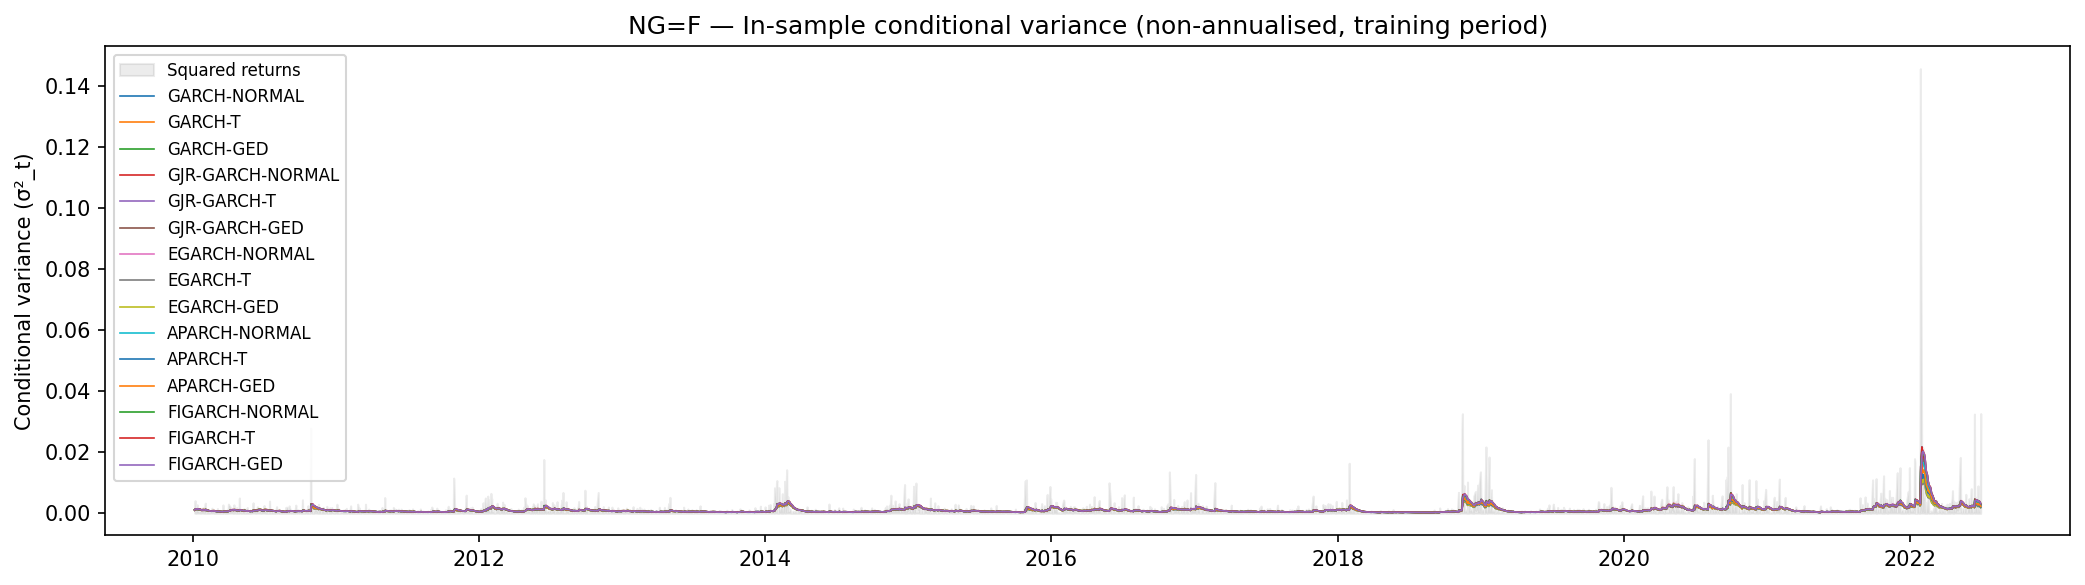

In [15]:
# In-sample conditional variance (non-annualised)
# Shows raw σ²_t as returned by each model
# PLOT_MODELS = ["GARCH-NORMAL", "GJR-GARCH-NORMAL", "EGARCH-NORMAL"]
PLOT_MODELS = [
    'GARCH-NORMAL', 'GARCH-T', 'GARCH-GED',
    'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED',
    'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED',
    'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED',
    'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED']

fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
ax.fill_between(
    train_returns.index.to_timestamp(),
    train_returns.values ** 2,
    alpha=0.15, color="gray", label="Squared returns",
)
for name in PLOT_MODELS:
    if name in insample_models:
        cv = insample_models[name].insample_variance()
        ax.plot(
            cv.index.to_timestamp(),
            cv.values,
            linewidth=0.8,
            label=name,
        )
ax.set_title(f"{TICKER} — In-sample conditional variance (non-annualised, training period)")
ax.set_ylabel("Conditional variance (σ²_t)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

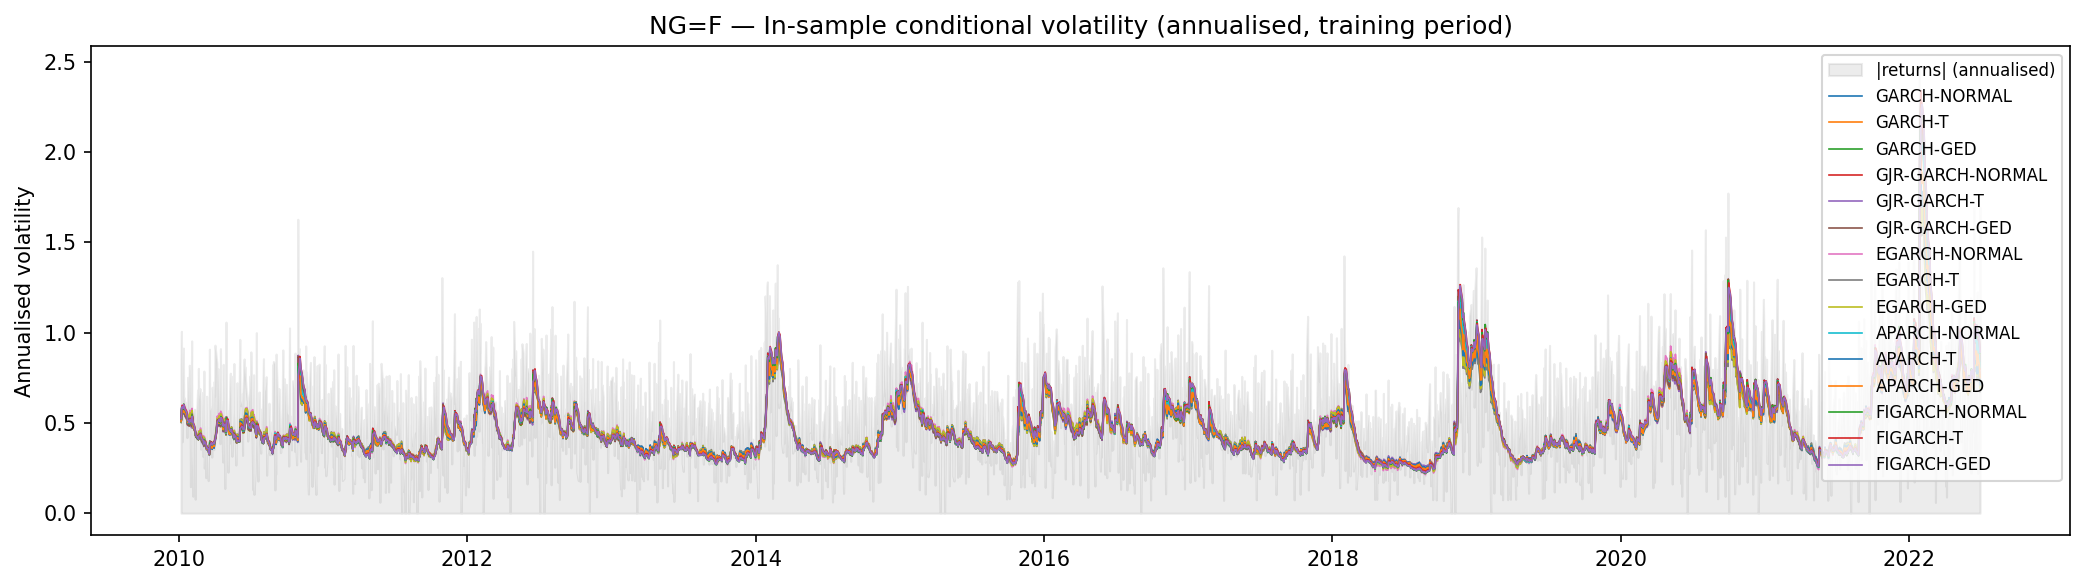

In [16]:
# In-sample conditional volatility — symmetric vs asymmetric comparison
# Shows annualised conditional standard deviation: sqrt(σ²_t × 252)
# PLOT_MODELS = ["GARCH-NORMAL", "GJR-GARCH-NORMAL", "EGARCH-NORMAL"]
PLOT_MODELS = [
    'GARCH-NORMAL', 'GARCH-T', 'GARCH-GED',
    'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED',
    'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED',
    'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED',
    'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED']

fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
ax.fill_between(
    train_returns.index.to_timestamp(),
    np.sqrt(np.abs(train_returns.values) * np.sqrt(252)),
    alpha=0.15, color="gray", label="|returns| (annualised)",
)
for name in PLOT_MODELS:
    if name in insample_models:
        cv = insample_models[name].insample_variance()
        ax.plot(
            cv.index.to_timestamp(),
            np.sqrt(cv.values * 252),
            linewidth=0.8,
            label=name,
        )
ax.set_title(f"{TICKER} — In-sample conditional volatility (annualised, training period)")
ax.set_ylabel("Annualised volatility")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4.2 Out-of-sample evaluation

Recursive one-step-ahead forecasting: at each step *t* the model is conditioned on all returns up to *t* and produces a forecast for *t+1*. Parameters are re-estimated every `REFIT_EVERY` steps.

**Window type:** `WINDOW_TYPE` — *expanding* uses all data from the start up to *t*; *sliding* keeps a fixed-width window of `WINDOW_SIZE` observations. A sliding window as wide as the training set (`WINDOW_SIZE=None`) overlaps almost entirely with the expanding window over a short test period and shows negligible differences — use a narrow width (e.g. 500–750) to probe regime sensitivity.

**Variance proxy:** `VARIANCE_PROXY` — the realized-variance series against which forecasts are evaluated. `garman_klass` (Garman-Klass 1980) uses OHLC data and is 5–8× less noisy than squared returns, which meaningfully increases the power of the DM test and MCS.

> **Note on QLIKE.** The reported QLIKE is `mean(log h_t + proxy_t / h_t)`, which equals the Patton (2011) robust QLIKE up to a model-independent additive constant (`−log(proxy) − 1`). Only *differences* and the *ordering* across models are interpretable — the absolute level (e.g. −6.5) carries no meaning on its own. Pairwise differences, DM and MCS are unaffected by the constant.

> **Note on RMSE across proxies.** RMSE magnitudes are not comparable between proxies (the target variable differs): Garman-Klass sits at a different level than r². Compare RMSE only *within* a proxy.

In [17]:
evaluator = RollingEvaluator(
    n_ahead=N_AHEAD,
    refit_every=REFIT_EVERY,
    window_type=WINDOW_TYPE,
    window_size=WINDOW_SIZE,
)

# functools.partial is picklable — required when PARALLEL_JOBS != 1.
# lambda would work for sequential (n_jobs=1) but cannot be sent to worker processes.
garch_eval_specs = [
    (partial(make_garch, t, d, asym_order=ASYM_ORDER), f"{t}-{d.upper()}")
    for t, d in GARCH_SPECS
]

garch_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    garch_eval_specs,
    train_returns,
    test_returns,
    actuals_series=variance_proxy,
    verbose=True,
    n_jobs=PARALLEL_JOBS,
)

_width = WINDOW_SIZE if (WINDOW_TYPE == "sliding" and WINDOW_SIZE is not None) else (
    len(train_returns) if WINDOW_TYPE == "sliding" else "n/a"
)
print(f"\nCompleted {len(garch_results)} models.")
print(f"Window type: {WINDOW_TYPE}  |  Window size: {_width}  |  Proxy: {VARIANCE_PROXY}")

Parallel evaluation: 15 models on 10 worker process(es)...
  [GARCH-NORMAL] done  RMSE=3.6313e-03
  [GJR-GARCH-NORMAL] done  RMSE=3.6340e-03
  [GARCH-T] done  RMSE=3.4397e-03
  [GARCH-GED] done  RMSE=3.5137e-03
  [EGARCH-NORMAL] done  RMSE=2.5565e-03
  [GJR-GARCH-T] done  RMSE=3.3253e-03
  [GJR-GARCH-GED] done  RMSE=3.4557e-03
  [EGARCH-T] done  RMSE=2.4266e-03
  [EGARCH-GED] done  RMSE=2.4707e-03
  [APARCH-NORMAL] done  RMSE=3.3954e-03
  [APARCH-GED] done  RMSE=2.9312e-03
  [APARCH-T] done  RMSE=2.6571e-03
  [FIGARCH-NORMAL] done  RMSE=3.7590e-03
  [FIGARCH-T] done  RMSE=3.3452e-03
  [FIGARCH-GED] done  RMSE=3.7366e-03

Completed 15 models.
Window type: expanding  |  Window size: n/a  |  Proxy: garman_klass


In [18]:
# Out-of-sample metrics table — ranked by RMSE
metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in garch_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
metrics_df

,RMSE,MAE,MSE,QLIKE
EGARCH-T,0.002427,0.001355,0.000006,-5.365356
EGARCH-GED,0.002471,0.001389,0.000006,-5.363602
EGARCH-NORMAL,0.002557,0.001454,0.000007,-5.357771
APARCH-T,0.002657,0.001409,0.000007,-5.357496
APARCH-GED,0.002931,0.001508,0.000009,-5.349804
GJR-GARCH-T,0.003325,0.001647,0.000011,-5.328479
FIGARCH-T,0.003345,0.001720,0.000011,-5.320879
APARCH-NORMAL,0.003395,0.001658,0.000012,-5.336609
GARCH-T,0.003440,0.001669,0.000012,-5.330543
GJR-GARCH-GED,0.003456,0.001685,0.000012,-5.328567


In [19]:
# Forecast-sanity screen — flags models whose forecasts are numerically degenerate
# and therefore corrupt the metrics / DM / MCS (e.g. a variance forecast collapsing
# toward 0 blows up QLIKE; exploding upward blows up RMSE). Emits a RuntimeWarning
# per affected model. Observed with EGARCH on short (~500-obs) sliding windows.
diag_df = forecast_diagnostics(garch_results)  # warns on any degenerate model

_bad = diag_df.index[diag_df["degenerate"]].tolist()
if _bad:
    print(f"⚠ DEGENERATE models — exclude before trusting DM/MCS: {_bad}\n")
else:
    print("✓ No degenerate forecasts — metrics are trustworthy.\n")

diag_df[["n", "min_forecast", "max_forecast", "n_extreme_low",
         "n_extreme_high", "RMSE", "QLIKE", "degenerate"]].style.map(
    lambda v: "background-color: #ffcdd2; font-weight: bold" if v is True else "",
    subset=["degenerate"],
).format({"min_forecast": "{:.2e}", "max_forecast": "{:.2e}",
          "RMSE": "{:.3e}", "QLIKE": "{:.3e}"})

✓ No degenerate forecasts — metrics are trustworthy.



,n,min_forecast,max_forecast,n_extreme_low,n_extreme_high,RMSE,QLIKE,degenerate
FIGARCH-T,1004,8.94e-04,2.32e-02,0,0,3.345e-03,-5.321e+00,False
FIGARCH-NORMAL,1004,8.04e-04,2.86e-02,0,0,3.759e-03,-5.321e+00,False
GARCH-NORMAL,1004,7.11e-04,2.63e-02,0,0,3.631e-03,-5.322e+00,False
FIGARCH-GED,1004,7.79e-04,2.88e-02,0,0,3.737e-03,-5.323e+00,False
GJR-GARCH-NORMAL,1004,7.11e-04,2.66e-02,0,0,3.634e-03,-5.325e+00,False
GARCH-GED,1004,7.20e-04,2.51e-02,0,0,3.514e-03,-5.328e+00,False
GJR-GARCH-T,1004,7.45e-04,2.26e-02,0,0,3.325e-03,-5.328e+00,False
GJR-GARCH-GED,1004,7.23e-04,2.45e-02,0,0,3.456e-03,-5.329e+00,False
GARCH-T,1004,7.39e-04,2.42e-02,0,0,3.440e-03,-5.331e+00,False
APARCH-NORMAL,1004,7.04e-04,2.44e-02,0,0,3.395e-03,-5.337e+00,False


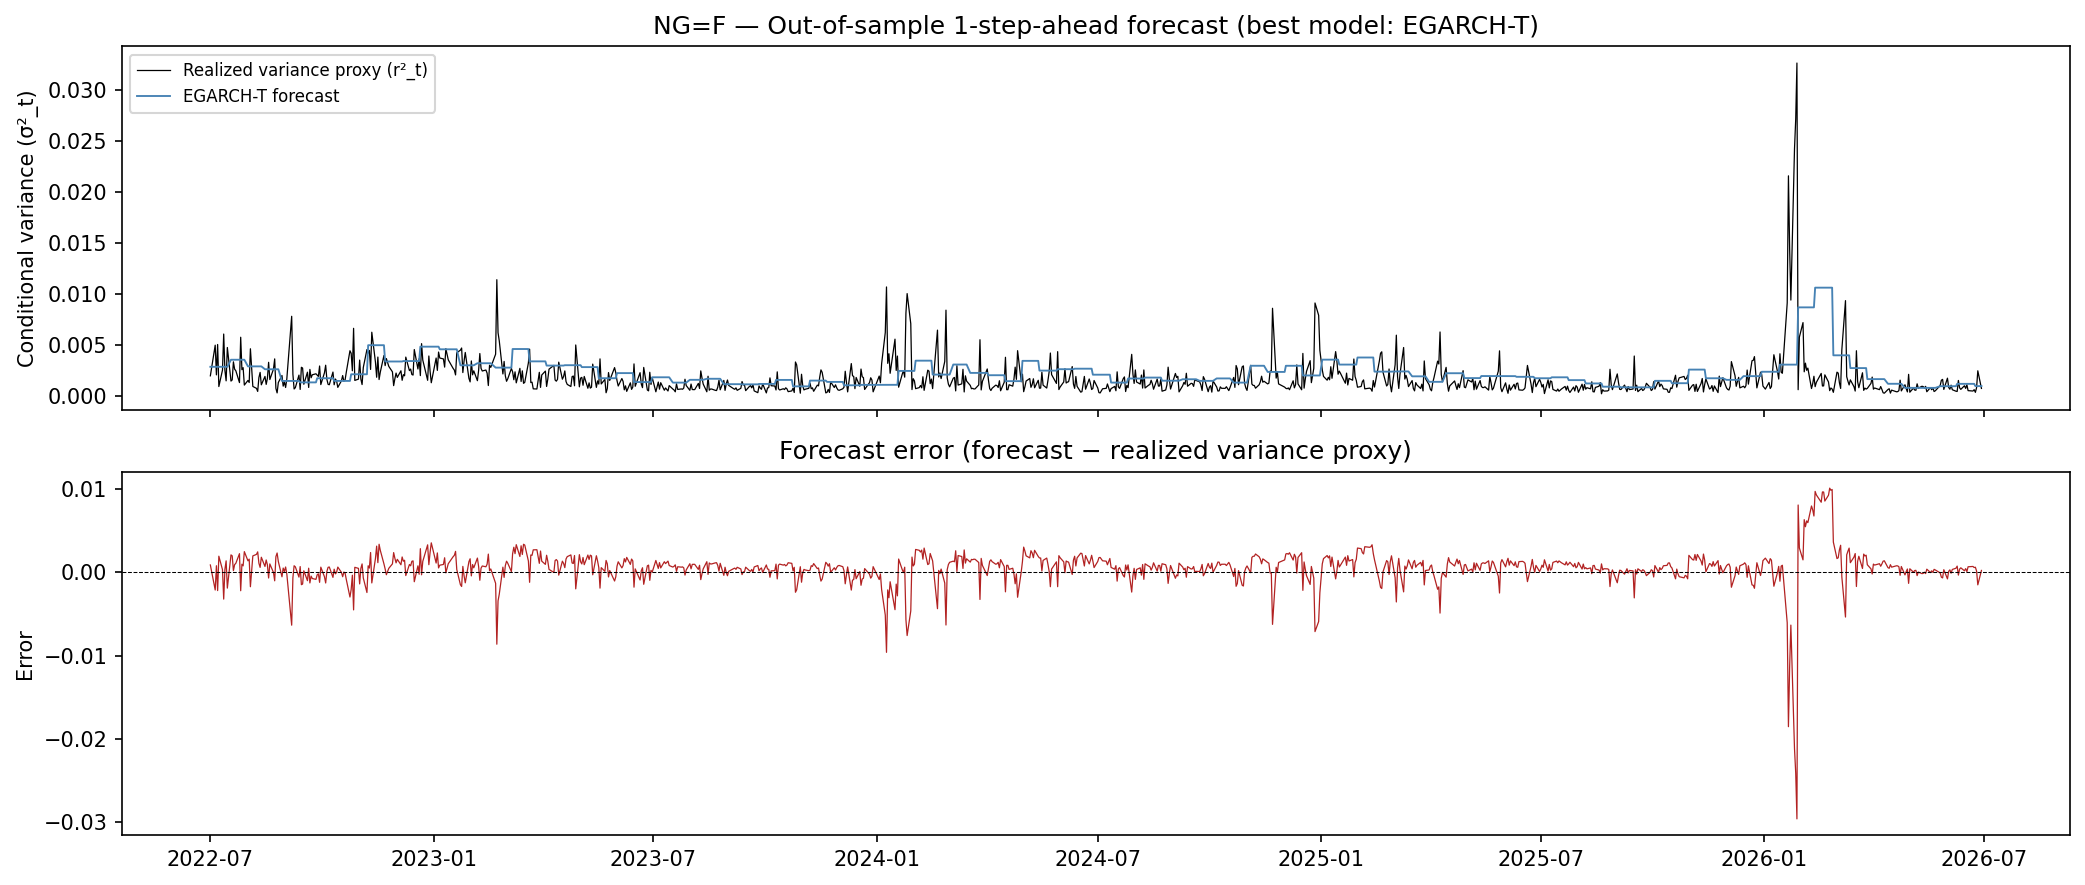

In [20]:
# Forecast vs realized — best model by RMSE (non-annualised)
# Shows raw variance: σ²_t forecast vs squared-return proxy
best_name = metrics_df.index[0]
r = garch_results[best_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)

ax0, ax1 = axes
ax0.plot(
    r.actuals.index.to_timestamp(),
    r.actuals.values,
    color="black", linewidth=0.6, label="Realized variance proxy (r²_t)",
)
ax0.plot(
    r.forecasts.index.to_timestamp(),
    r.forecasts.values,
    color="steelblue", linewidth=0.9, label=f"{best_name} forecast",
)
ax0.set_title(f"{TICKER} — Out-of-sample 1-step-ahead forecast (best model: {best_name})")
ax0.set_ylabel("Conditional variance (σ²_t)")
ax0.legend(fontsize=8)

ax1.plot(
    r.errors.index.to_timestamp(),
    r.errors.values,
    color="firebrick", linewidth=0.6,
)
ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax1.set_title("Forecast error (forecast − realized variance proxy)")
ax1.set_ylabel("Error")

plt.tight_layout()
plt.show()

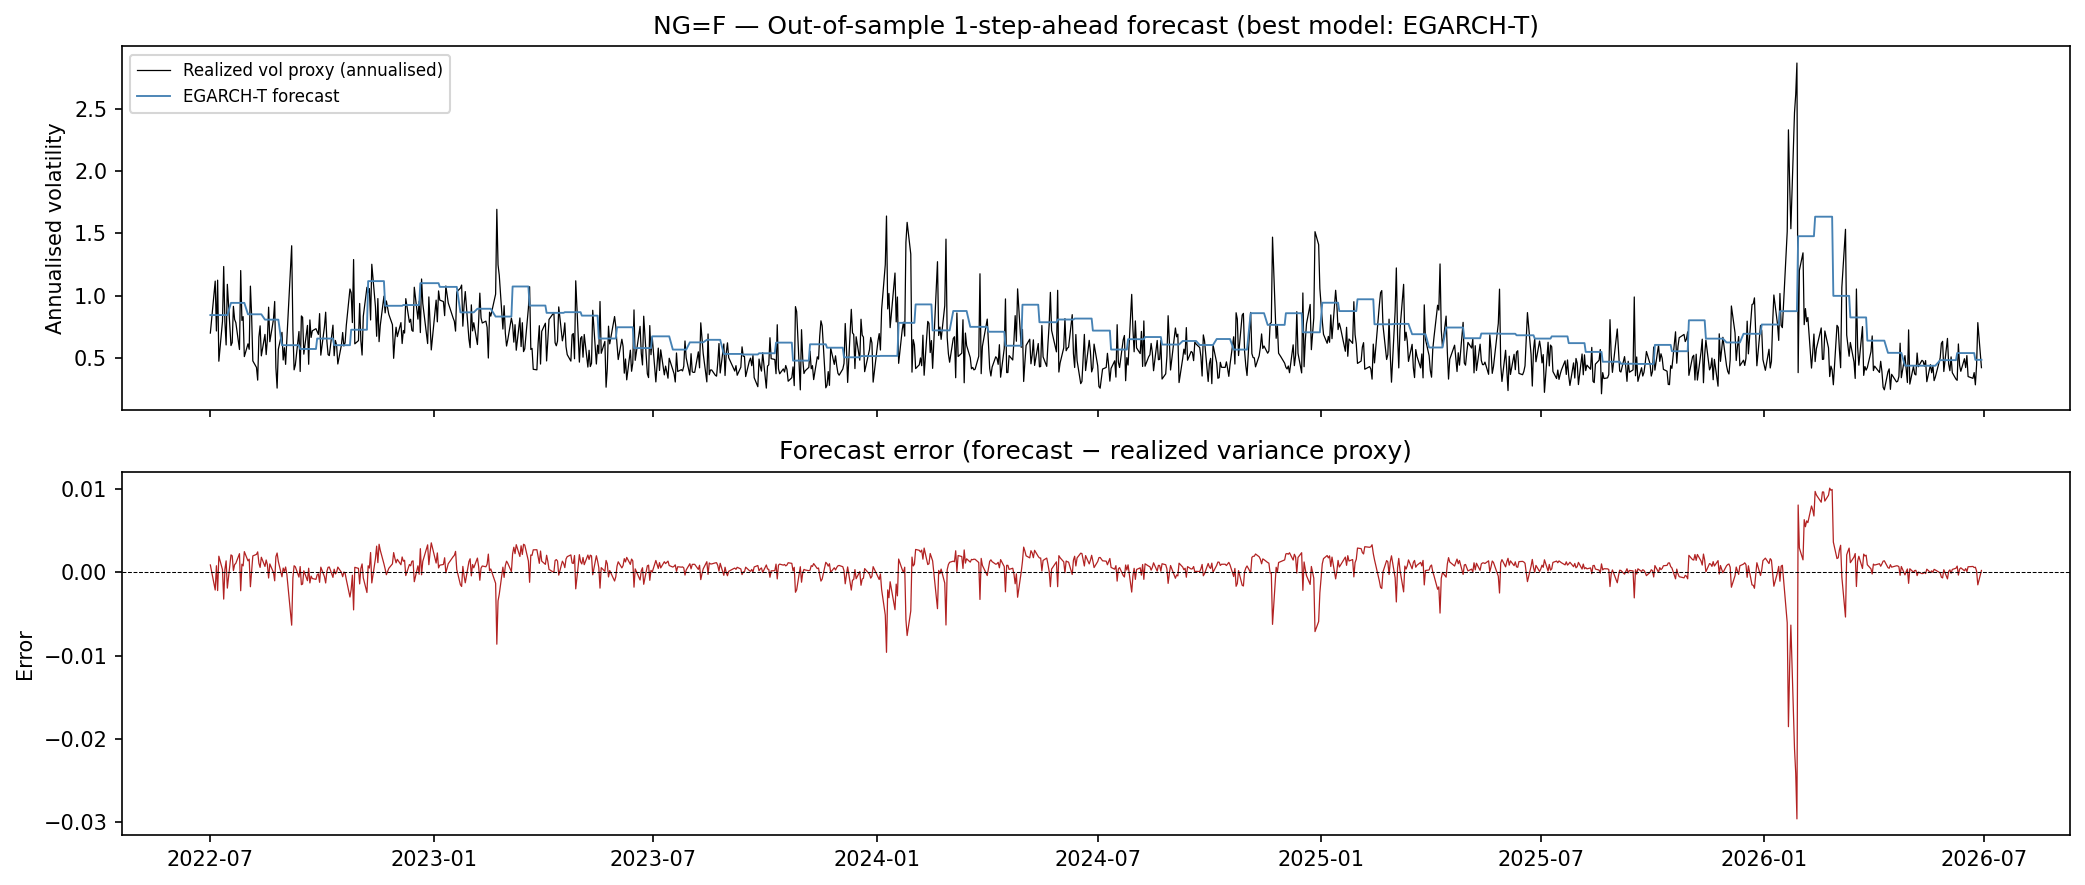

In [21]:
# Forecast vs realized — best model by RMSE
best_name = metrics_df.index[0]
r = garch_results[best_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)

ax0, ax1 = axes
ax0.plot(
    r.actuals.index.to_timestamp(),
    np.sqrt(r.actuals.values * 252),
    color="black", linewidth=0.6, label="Realized vol proxy (annualised)",
)
ax0.plot(
    r.forecasts.index.to_timestamp(),
    np.sqrt(r.forecasts.values * 252),
    color="steelblue", linewidth=0.9, label=f"{best_name} forecast",
)
ax0.set_title(f"{TICKER} — Out-of-sample 1-step-ahead forecast (best model: {best_name})")
ax0.set_ylabel("Annualised volatility")
ax0.legend(fontsize=8)

ax1.plot(
    r.errors.index.to_timestamp(),
    r.errors.values,
    color="firebrick", linewidth=0.6,
)
ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax1.set_title("Forecast error (forecast − realized variance proxy)")
ax1.set_ylabel("Error")

plt.tight_layout()
plt.show()

# 5. Statistical Tests

## 5.1 Diebold-Mariano Test (HLN correction)

Pairwise test of equal predictive accuracy (Harvey, Leybourne & Newbold 1997).  
H₀: models *i* and *j* have equal expected loss.  
Negative MDM statistic → row model has lower loss than column model.  
p-values are two-sided from a *t*(T−1) distribution.

In [22]:
dm_stat_df, dm_pval_df = dm_matrix(garch_results, h=N_AHEAD, loss=TEST_LOSS)

print("MDM statistics (upper triangle):")
dm_stat_df.round(3)

MDM statistics (upper triangle):


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,APARCH-T,APARCH-GED,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED
GARCH-NORMAL,NaN,5.945,6.588,4.884,3.094,6.301,7.450,7.755,8.040,10.945,7.535,9.076,-0.714,-0.557,0.356
GARCH-T,NaN,NaN,-4.750,-3.512,-2.094,-3.111,5.669,6.773,6.745,3.611,6.758,7.520,-3.435,-3.371,-2.486
GARCH-GED,NaN,NaN,NaN,-2.757,0.400,1.521,6.311,7.133,7.229,6.355,7.075,8.315,-2.949,-2.511,-1.833
GJR-GARCH-NORMAL,NaN,NaN,NaN,NaN,1.625,3.095,6.912,7.167,7.456,8.890,6.729,7.847,-2.215,-1.316,-0.798
GJR-GARCH-T,NaN,NaN,NaN,NaN,NaN,0.084,6.247,7.718,7.551,4.056,8.279,9.314,-2.323,-2.513,-1.592
GJR-GARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,6.336,7.221,7.303,6.145,7.186,8.528,-3.151,-2.688,-2.048
EGARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.852,5.250,-5.715,-0.087,-2.768,-8.051,-8.398,-7.659
EGARCH-T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.008,-6.357,-3.708,-5.308,-7.815,-9.031,-7.515
EGARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.628,-2.509,-5.043,-8.283,-9.246,-7.948
APARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.637,6.639,-7.965,-5.540,-5.819


In [23]:
print("DM p-values (upper triangle) — highlighted cells: p < DM_ALPHA")
dm_pval_df.round(4).style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold"
    if (not pd.isna(v) and v < DM_ALPHA)
    else "",
)

DM p-values (upper triangle) — highlighted cells: p < DM_ALPHA


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,APARCH-T,APARCH-GED,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED
GARCH-NORMAL,nan,0.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.475500,0.577400,0.721800
GARCH-T,nan,nan,0.000000,0.000500,0.036500,0.001900,0.000000,0.000000,0.000000,0.000300,0.000000,0.000000,0.000600,0.000800,0.013100
GARCH-GED,nan,nan,nan,0.005900,0.689600,0.128500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003300,0.012200,0.067100
GJR-GARCH-NORMAL,nan,nan,nan,nan,0.104400,0.002000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027000,0.188500,0.425200
GJR-GARCH-T,nan,nan,nan,nan,nan,0.932800,0.000000,0.000000,0.000000,0.000100,0.000000,0.000000,0.020400,0.012100,0.111700
GJR-GARCH-GED,nan,nan,nan,nan,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001700,0.007300,0.040800
EGARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,0.000100,0.000000,0.000000,0.930700,0.005700,0.000000,0.000000,0.000000
EGARCH-T,nan,nan,nan,nan,nan,nan,nan,nan,0.044900,0.000000,0.000200,0.000000,0.000000,0.000000,0.000000
EGARCH-GED,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,0.012300,0.000000,0.000000,0.000000,0.000000
APARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000


### 5.1.1 DM within-family vs between-family split

Counting raw significant DM pairs overstates model separability for two reasons:

1. **Multiplicity.** With 15 models there are 105 pairwise tests; ~5 would be significant at 5% by chance alone, and there is no family-wise correction here (that is what MCS provides).
2. **(Near-)nesting.** Models sharing the same variance equation and differing only in the error distribution (e.g. GARCH-NORMAL vs GARCH-T, where Normal is the limiting case of the Student-t) are nearly nested. Under H₀ the loss-differential variance is near-degenerate, which inflates the DM statistic and makes the standard test oversized (Clark-McCracken; Giacomini-White 2006).

Splitting the matrix into **within-family** (nested, distribution-only) and **between-family** (architecture) comparisons separates likely-spurious within-family rejections from the more meaningful between-family ones.

In [24]:
split = dm_family_split(dm_pval_df, alpha=DM_ALPHA)

total_sig = split["within"]["n_significant"] + split["between"]["n_significant"]
total_pairs = split["within"]["n_total"] + split["between"]["n_total"]
print(f"DM significant pairs ({TEST_LOSS} loss, p < {DM_ALPHA}): "
      f"{total_sig} / {total_pairs} total\n")

summary_split = pd.DataFrame({
    "n_significant": [split["within"]["n_significant"], split["between"]["n_significant"]],
    "n_total":       [split["within"]["n_total"],       split["between"]["n_total"]],
    "rejection_rate":[split["within"]["rate"],          split["between"]["rate"]],
}, index=["within-family (nested)", "between-family (architecture)"])
print(summary_split.to_string(formatters={"rejection_rate": "{:.1%}".format}))

# Most-rejected models among between-family pairs (the genuine signal)
from collections import Counter
node = Counter()
for a, b, p in split["between"]["pairs"]:
    if p < DM_ALPHA:
        node[a] += 1
        node[b] += 1
print("\nMost frequently rejected models (between-family pairs):")
for name, cnt in node.most_common(5):
    print(f"  {name:<20} appears in {cnt} significant between-family pairs")

DM significant pairs (qlike loss, p < 0.05): 91 / 105 total

                               n_significant  n_total rejection_rate
within-family (nested)                    11       15          73.3%
between-family (architecture)             80       90          88.9%

Most frequently rejected models (between-family pairs):
  APARCH-NORMAL        appears in 12 significant between-family pairs
  APARCH-GED           appears in 12 significant between-family pairs
  EGARCH-GED           appears in 12 significant between-family pairs
  EGARCH-T             appears in 12 significant between-family pairs
  GARCH-T              appears in 12 significant between-family pairs


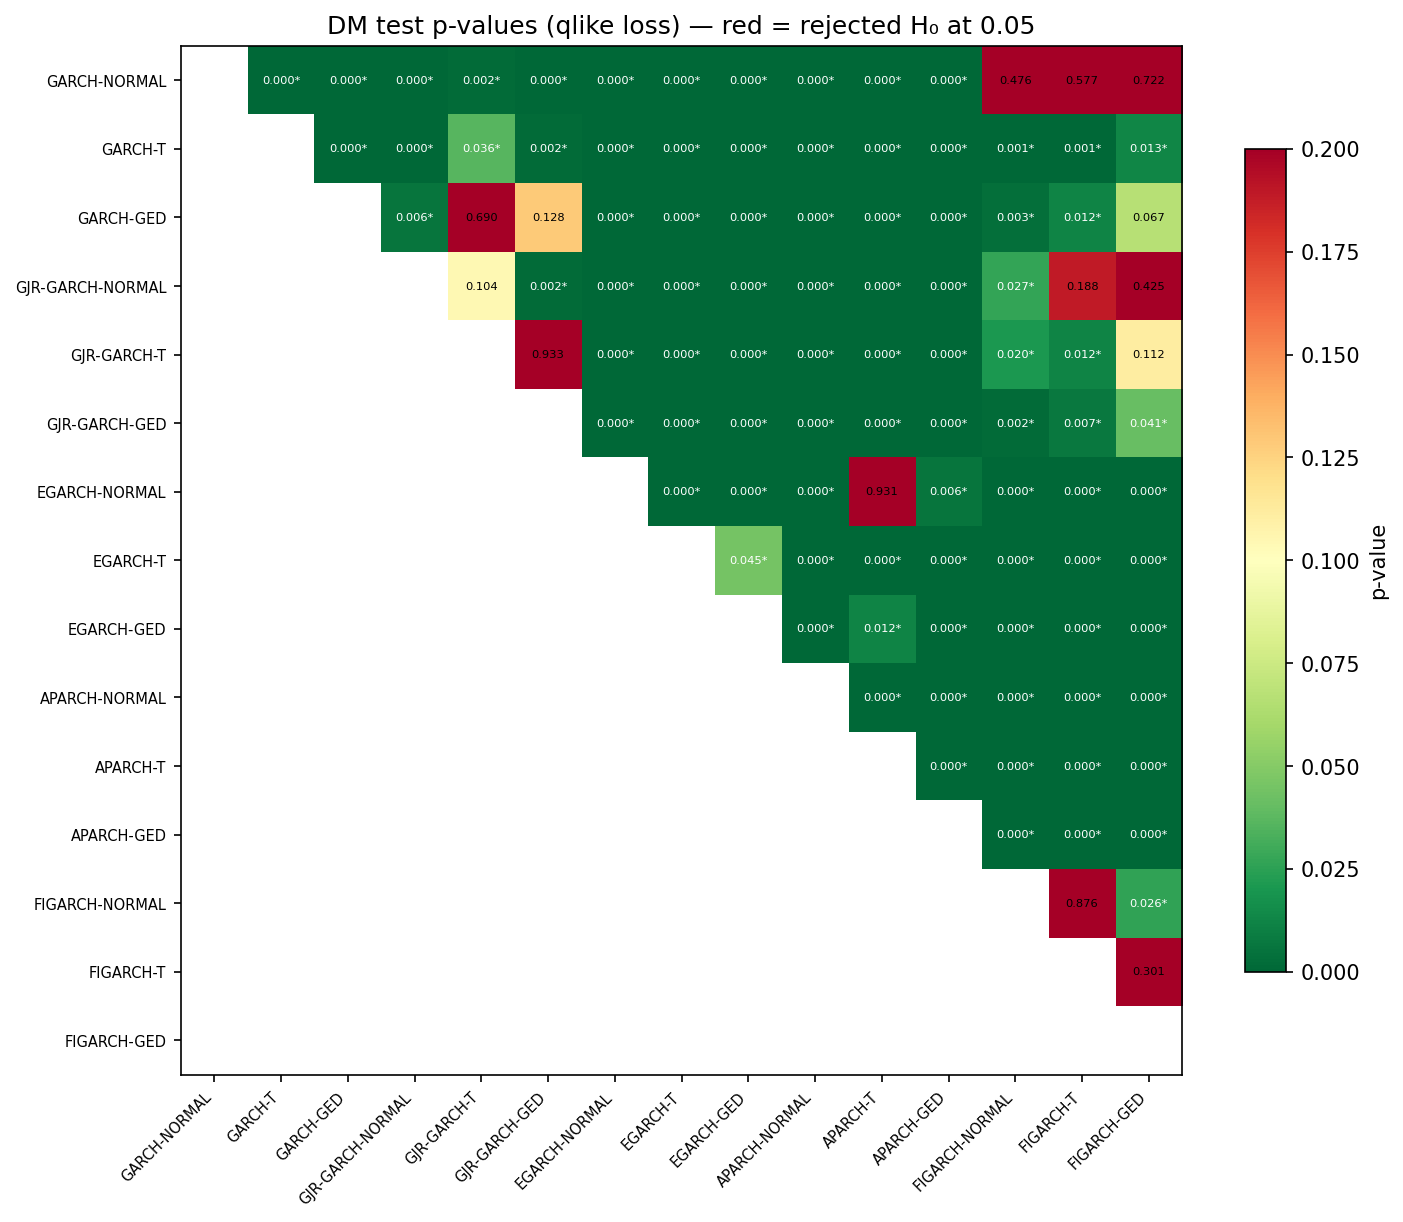

In [25]:
# DM p-value heatmap (upper triangle only)
names  = list(garch_results.keys())
n_mods = len(names)
pvals  = dm_pval_df.values.astype(float)

# Mask lower triangle + diagonal (show upper triangle only)
mask       = np.tril(np.ones_like(pvals, dtype=bool))
pvals_plot = np.where(mask, np.nan, pvals)

fig, ax = plt.subplots(figsize=(max(8, n_mods * 0.65), max(6, n_mods * 0.55)), dpi=150)
im = ax.imshow(pvals_plot, cmap="RdYlGn_r", vmin=0, vmax=0.20, aspect="auto")
plt.colorbar(im, ax=ax, label="p-value", shrink=0.8)

ax.set_xticks(range(n_mods))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_mods))
ax.set_yticklabels(names, fontsize=7)
ax.set_title(f"DM test p-values ({TEST_LOSS} loss) — red = rejected H₀ at {DM_ALPHA}")

for i in range(n_mods):
    for j in range(i + 1, n_mods):
        v = pvals[i, j]
        if not np.isnan(v):
            sig = "*" if v < DM_ALPHA else ""
            ax.text(j, i, f"{v:.3f}{sig}", ha="center", va="center", fontsize=5.5,
                    color="white" if v < 0.05 else "black")

plt.tight_layout()
plt.show()

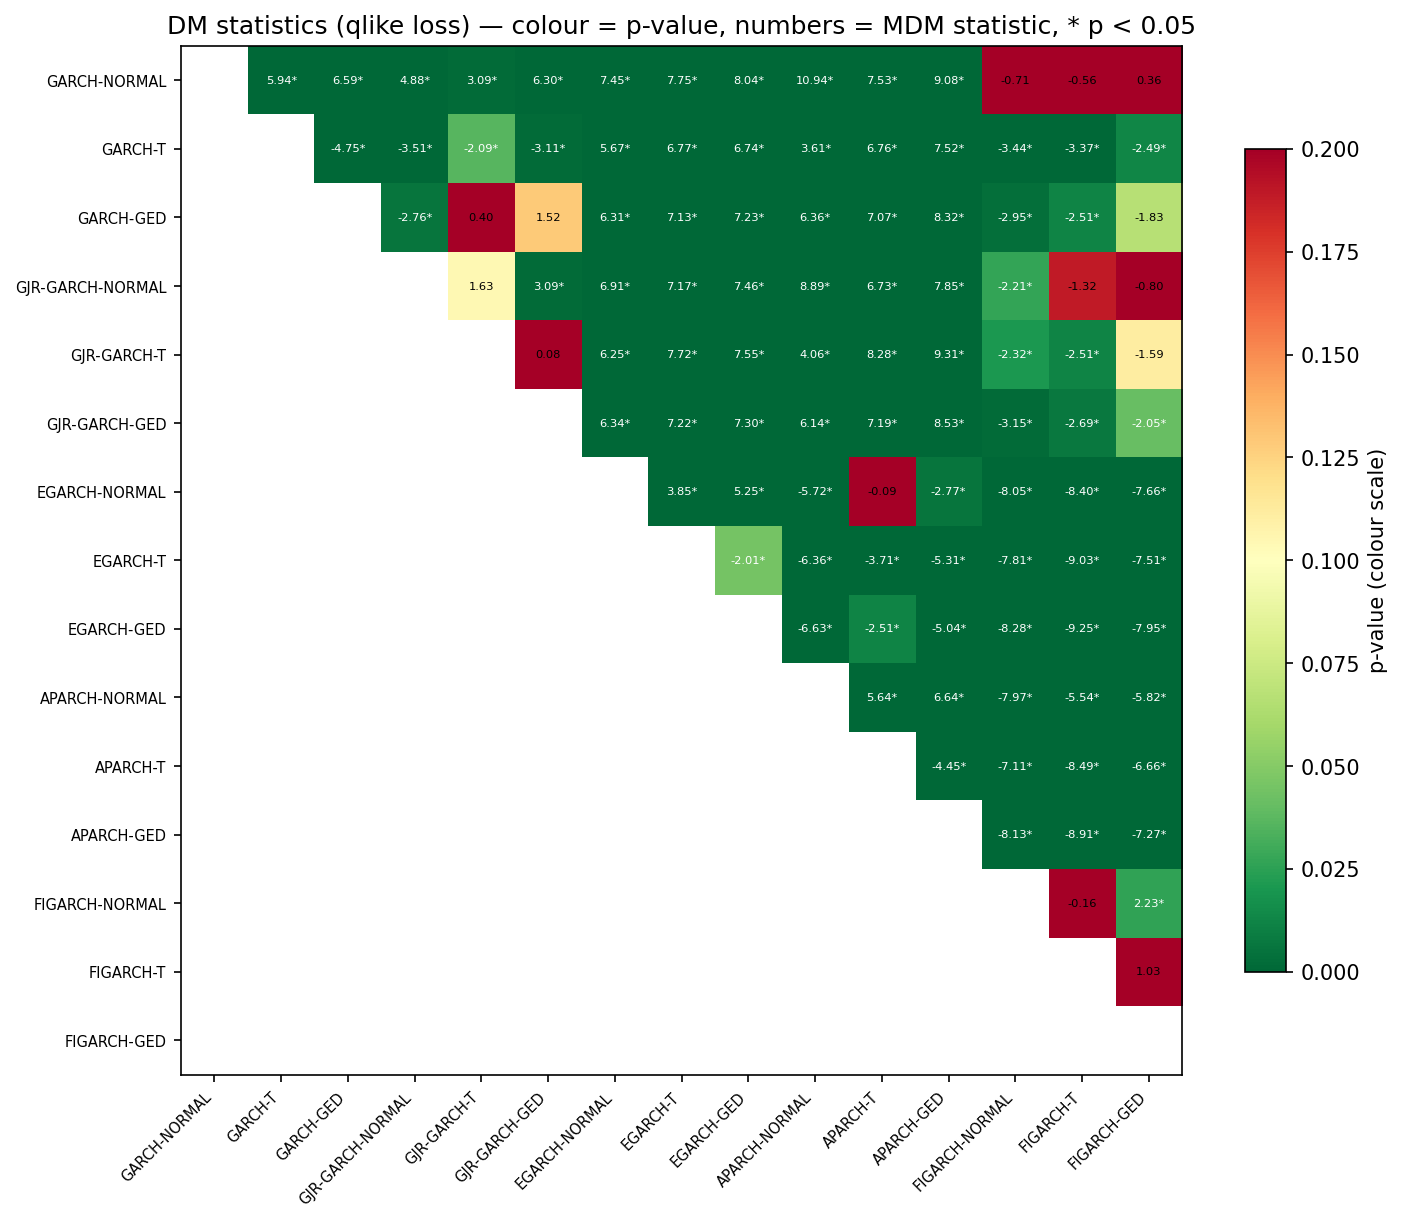

In [26]:
# DM statistics heatmap — colour based on p-value, numbers show DM statistic
names  = list(garch_results.keys())
n_mods = len(names)
pvals  = dm_pval_df.values.astype(float)
stats  = dm_stat_df.values.astype(float)

mask       = np.tril(np.ones_like(pvals, dtype=bool))
pvals_plot = np.where(mask, np.nan, pvals)
stats_plot = np.where(mask, np.nan, stats)

fig, ax = plt.subplots(figsize=(max(8, n_mods * 0.65), max(6, n_mods * 0.55)), dpi=150)
im = ax.imshow(pvals_plot, cmap="RdYlGn_r", vmin=0, vmax=0.20, aspect="auto")
plt.colorbar(im, ax=ax, label="p-value (colour scale)", shrink=0.8)

ax.set_xticks(range(n_mods))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_mods))
ax.set_yticklabels(names, fontsize=7)
ax.set_title(f"DM statistics ({TEST_LOSS} loss) — colour = p-value, numbers = MDM statistic, * p < {DM_ALPHA}")

for i in range(n_mods):
    for j in range(i + 1, n_mods):
        s = stats_plot[i, j]
        p = pvals_plot[i, j]
        if not np.isnan(s):
            sig = "*" if p < DM_ALPHA else ""
            ax.text(j, i, f"{s:.2f}{sig}", ha="center", va="center", fontsize=5.5,
                    color="white" if p < 0.05 else "black")

plt.tight_layout()
plt.show()

## 5.2 Model Confidence Set (MCS)

Hansen, Lunde & Nason (2011). Sequential elimination of the worst model using the T_max statistic until the null of equal predictive accuracy cannot be rejected. Inference via stationary bootstrap (Politis & Romano 1994).

Models with `mcs_pvalue > MCS_ALPHA` belong to the (1 − MCS_ALPHA) MCS.

In [27]:
mcs_result = mcs(
    garch_results,
    loss=TEST_LOSS,
    alpha=MCS_ALPHA,
    n_boot=N_BOOT,
    seed=RANDOM_SEED,
)
print(mcs_result)
print()

# NOTE: this procedure stops at the first non-rejection (Hansen et al. 2011),
# so surviving models are NOT assigned a real bootstrap p-value — they share the
# placeholder 1.0. mark_early_stop=True shows those as "—" (early_stop=True) so
# they are not misread as genuine p-values. For graded within-set p-values, see
# arch_mcs below.
mcs_result.summary(mark_early_stop=True).style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold" if v is True else "",
    subset=["in_mcs"],
).format({"mcs_pvalue": "{:.4f}"}, na_rep="—")

MCSResult(alpha=0.05, loss='qlike', n_included=6, models=['GARCH-T', 'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED', 'APARCH-T', 'APARCH-GED'])



,mcs_pvalue,in_mcs,early_stop
GARCH-T,—,True,True
EGARCH-NORMAL,—,True,True
EGARCH-T,—,True,True
EGARCH-GED,—,True,True
APARCH-T,—,True,True
APARCH-GED,—,True,True
GARCH-GED,0.0430,False,False
APARCH-NORMAL,0.0430,False,False
GJR-GARCH-GED,0.0355,False,False
GJR-GARCH-T,0.0215,False,False


### 5.2.1 MCS cross-check — arch.bootstrap.MCS (Sheppard)

Independent verification using Kevin Sheppard's `arch.bootstrap.MCS` implementation (T_max statistic).

**Interpretation:**
- If both implementations agree (same models survive / same models all-included) → the result is consistent.
- If both retain the full set with `squared` proxy but a subset survives with `garman_klass` → the earlier all-p=1 result was caused by a noisy proxy, not an implementation bug.
- If the two implementations disagree for the same proxy → there is a bug in our custom MCS.

In [28]:
arch_mcs_result = arch_mcs(
    garch_results,
    loss=TEST_LOSS,
    size=MCS_ALPHA,
    n_boot=N_BOOT,
    seed=RANDOM_SEED,
)

print(f"arch.bootstrap.MCS — {TEST_LOSS} loss, alpha={MCS_ALPHA}")
print(f"Models in MCS: {arch_mcs_result['in_mcs'].sum()} / {len(arch_mcs_result)}")
print()

# Side-by-side comparison. our_pvalue is "—" for early-stop survivors (placeholder,
# not a real bootstrap value); arch_pvalue gives the graded within-set p-values
# that rank how robustly each model belongs to the MCS. Report arch_pvalue.
comparison = (
    mcs_result.summary(mark_early_stop=True)
    .rename(columns={"mcs_pvalue": "our_pvalue", "in_mcs": "our_in_mcs"})
    .drop(columns=["early_stop"])
)
comparison = comparison.join(
    arch_mcs_result.rename(columns={"mcs_pvalue": "arch_pvalue", "in_mcs": "arch_in_mcs"})
)
comparison.style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold" if v is True else "",
    subset=["our_in_mcs", "arch_in_mcs"],
).format({"our_pvalue": "{:.4f}", "arch_pvalue": "{:.4f}"}, na_rep="—")

arch.bootstrap.MCS — qlike loss, alpha=0.05
Models in MCS: 10 / 15



,our_pvalue,our_in_mcs,arch_pvalue,arch_in_mcs
GARCH-T,—,True,0.1315,True
EGARCH-NORMAL,—,True,0.4690,True
EGARCH-T,—,True,1.0000,True
EGARCH-GED,—,True,0.4690,True
APARCH-T,—,True,0.4690,True
APARCH-GED,—,True,0.2155,True
GARCH-GED,0.0430,False,0.0675,True
APARCH-NORMAL,0.0430,False,0.0550,True
GJR-GARCH-GED,0.0355,False,0.0550,True
GJR-GARCH-T,0.0215,False,0.0810,True
